In [1]:
def find_multiple_regress(data, variable):    
    model = smf.ols(f"Q('10cm_area') ~ max_precip + {variable}", data=data).fit()
    r2 = model.rsquared
    p_value = model.pvalues[variable]
    
    if p_value <0.005:
        p_value = '<0.05'
    else:
        p_value = round(p_value, 2)
    return r2, p_value

def find_linear_relationship (df, variable1, variable2):
    x = df[variable2]
    y = df[variable1]

    # Simple regression: flood area ~ rainfall intensity
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2_simple = r_value**2
    if p_value <0.005:
        p_value = '<0.05'
    else:
        p_value = round(p_value, 2)
    # print(" Simple:", f"{r2_simple:.2f}", p_value)  
    return [r2_simple, p_value]

def plot_r2_grid(df, suptitle, dividing_variable, xvar="max_precip", yvar="10cm_area"):
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.ravel()

    for ax, (_, row) in zip(axes, df.iterrows()):
        
        if dividing_variable =='geo_region':
            catchment_name = row['geo_region']
        elif dividing_variable =='catchment_num':
            catchment_name = CATCHMENT_LOOKUP_DICT[row['catchment_num']]            
        
        sub = rainfall_events_all_df[rainfall_events_all_df[dividing_variable] == row[dividing_variable]
        ].dropna(subset=[xvar, yvar, "hc_at_peak"])   # same filter as the regression
        sub = sub[sub['10cm_area']>0]
        ax.scatter(sub[xvar], sub[yvar], s=20, alpha=0.8)

        # regression line for display
        if len(sub) > 1:
            m, c = np.polyfit(sub[xvar], sub[yvar], 1)
            xs = np.linspace(sub[xvar].min(), sub[xvar].max(), 50)
            ax.plot(xs, m * xs + c, color="red", lw=1.5)
            
        ax.set_title(f"{catchment_name} \n (R² = {row['r2_simple']:.2f}, p = {row['p_simple']}, n = {len(sub)}",
                     #f"\n With FUmax : R² = {row['r2_fumax']:.2f}, p = {row['p_fumax']}, n = {len(sub)}  "
                     #f"\n With FU : R² = {row['r2_fu']:.2f}, p = {row['p_fu']}, n = {len(sub)})",
                     fontsize=12)
        ax.set_xlabel(xvar)
        ax.set_ylabel(yvar)
        ax.set_xlabel(xvar)
        ax.set_ylabel(yvar)

    for ax in axes[len(df):]:      # hide any unused panels
        ax.set_visible(False)

    fig.suptitle(suptitle, fontsize=13)
    fig.tight_layout()
    return fig

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, linregress
import matplotlib.pyplot as plt
import sys
import geopandas as gpd
import statsmodels.formula.api as smf
import scipy.stats as stats

sys.path.insert(1, '../ProcessEvents')
from config import CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, CATCHMENTS

In [3]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails_v4/all_catchments.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df["length"] = (rainfall_events_all_df["stop_idx"] - rainfall_events_all_df["start_idx"]).astype("float32")

In [4]:
regions_shp = "/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/#ss/plots/most_exposed_events_visualisation/by_region/ukcp18-uk-land-region-hires.shp"
regions_df = gpd.read_file(regions_shp)
regions_df["region_geometry"] = regions_df.geometry

catchments_df = CATCHMENTS
catchments_df["catchment_geometry"] = catchments_df.geometry

# Event points
rainfall_events_all_df = gpd.GeoDataFrame(rainfall_events_all_df,
                        geometry=gpd.points_from_xy(rainfall_events_all_df["x_coord"], rainfall_events_all_df["y_coord"]), 
                                          crs=regions_df.crs)

# Remove old sjoin columns if this dataframe has been joined before
rainfall_events_all_df = rainfall_events_all_df.drop(
    columns=["index_right", "geo_region", "region_geometry", "HA_NAME", "catchment_geometry"], errors="ignore")

# Join regions
rainfall_events_all_df = gpd.sjoin(rainfall_events_all_df, regions_df[["geo_region", "region_geometry", "geometry"]],
    how="left", predicate="within")

# Drop index_right before the next sjoin, or geopandas will error on the clash
rainfall_events_all_df = rainfall_events_all_df.drop(columns=["index_right"], errors="ignore")

# Join catchments
rainfall_events_all_df = gpd.sjoin(rainfall_events_all_df, catchments_df[["HA_NAME", "catchment_geometry", "geometry"]],
    how="left", predicate="within")

rainfall_events_all_df = rainfall_events_all_df.drop(columns=["index_right"], errors="ignore")

### Using the whole dataset

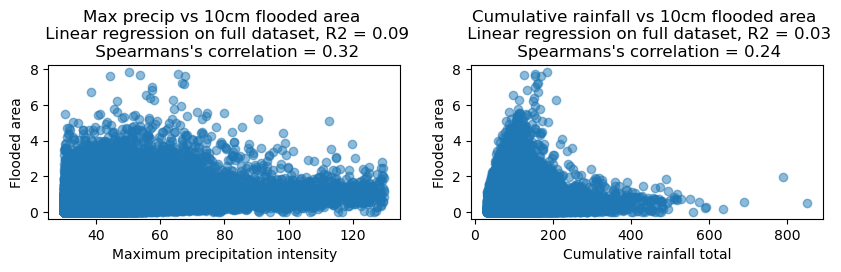

In [5]:
fig,axs=plt.subplots(ncols=2,figsize=(10,2))

r2_simple, p_value = find_linear_relationship(rainfall_events_all_df,'max_precip', "10cm_area")
spearmans_corr, spearmans_p_value = stats.spearmanr(rainfall_events_all_df["max_precip"], rainfall_events_all_df["10cm_area"])
axs[0].scatter(rainfall_events_all_df['max_precip'], rainfall_events_all_df['10cm_area'], alpha=0.5)
axs[0].set_title(f"Max precip vs 10cm flooded area \n Linear regression on full dataset, R2 = {r2_simple:.2f}"
                  f"\n Spearmans's correlation = {spearmans_corr:.2f}");
axs[0].set_xlabel('Maximum precipitation intensity')
axs[0].set_ylabel('Flooded area')

r2_simple, p_value = find_linear_relationship(rainfall_events_all_df, 'total_acc', "10cm_area")
spearmans_corr, spearmans_p_value = stats.spearmanr(rainfall_events_all_df["total_acc"], rainfall_events_all_df["10cm_area"])
axs[1].scatter(rainfall_events_all_df['total_acc'], rainfall_events_all_df['10cm_area'], alpha=0.5)
axs[1].set_title(f"Cumulative rainfall vs 10cm flooded area \n Linear regression on full dataset, R2 = {r2_simple:.2f}"
                f"\n Spearmans's correlation = {spearmans_corr:.2f}")
axs[1].set_xlabel('Cumulative rainfall total')
axs[1].set_ylabel('Flooded area');

### Per region

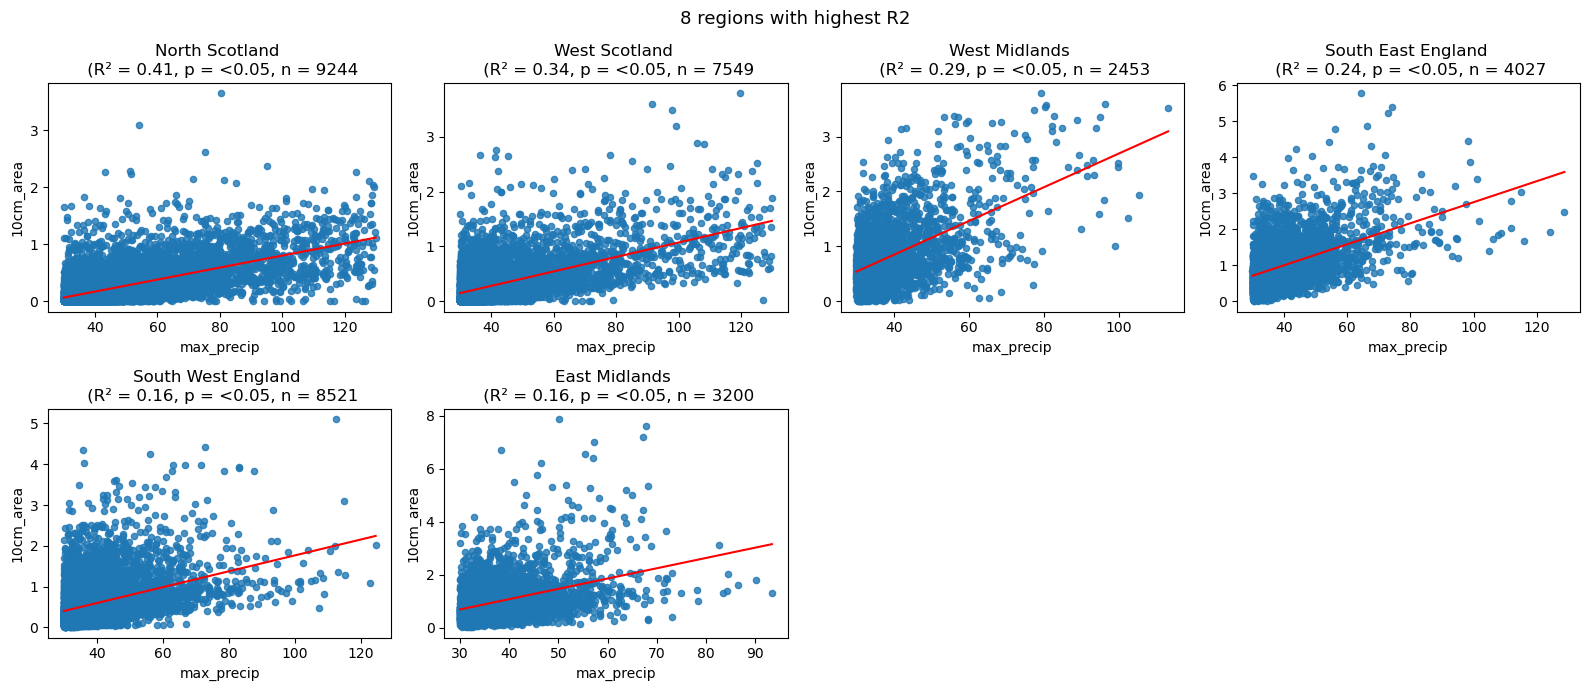

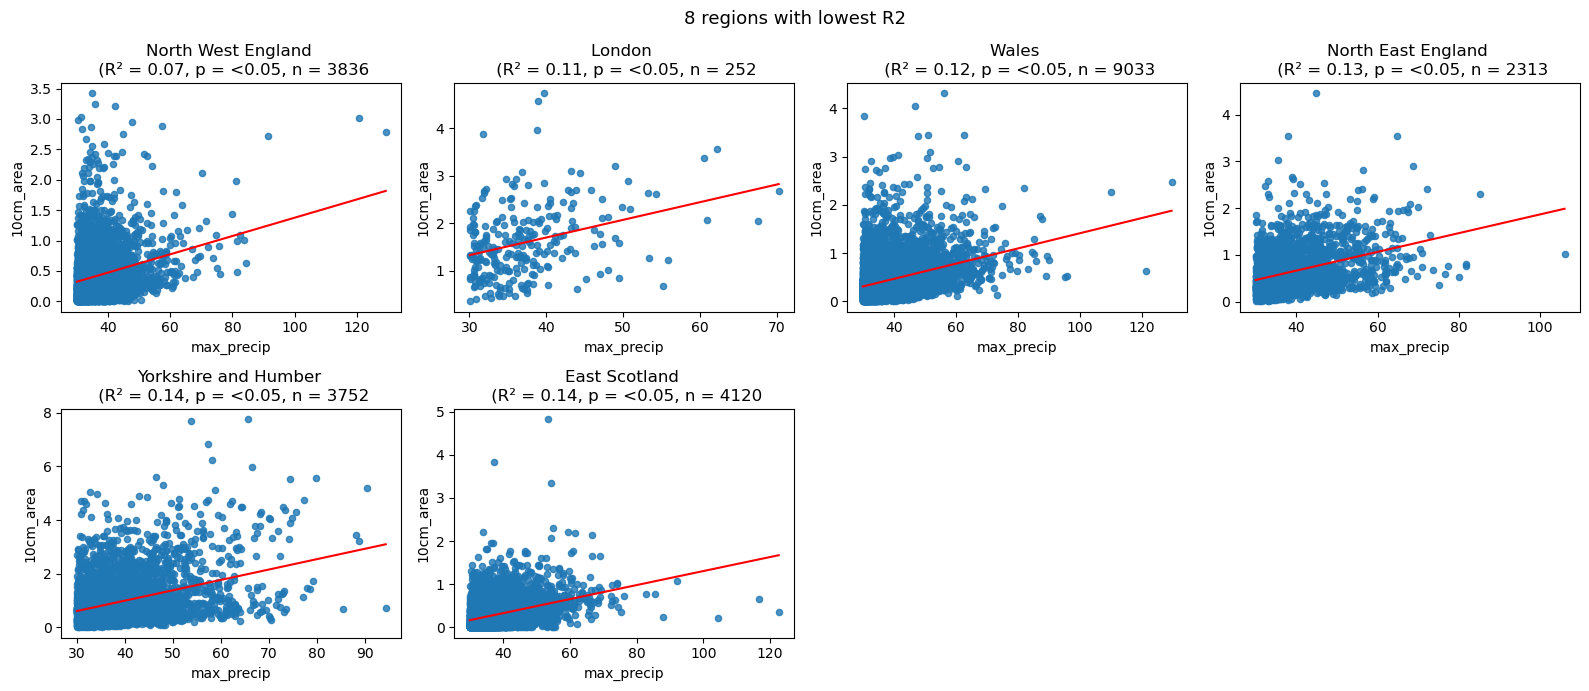

In [6]:
results = []

for region in np.unique(rainfall_events_all_df["geo_region"]):

    subset = rainfall_events_all_df[rainfall_events_all_df["geo_region"] == region].dropna(
        subset=["max_precip", "10cm_area", "hc_at_peak"])

    subset = subset[subset["10cm_area"] > 0]

    # Simple: flood area ~ rainfall intensity
    r2_simple, p_simple = find_linear_relationship(subset, "10cm_area", "max_precip")
    
    spearmans_corr, spearmans_p_value = stats.spearmanr(subset["10cm_area"], subset["max_precip"])

    # Multiple: flood area ~ rainfall intensity + fu_at_peak
    r2_fu, p_fu = find_multiple_regress (subset, "fu_at_peak_old")
    r2_fumax, p_fumax = find_multiple_regress (subset, "fumax_at_peak")

    results.append({"geo_region": region,"r2_simple": r2_simple, "spearmans_corr":  spearmans_corr, "p_simple": p_simple,
        "r2_fu": r2_fu,"p_fu": p_fu, 
#                     "r2_fumax": model_fumax.rsquared, "p_fumax": model_fumax.pvalues["fumax_at_peak"]
                   })

results_df = pd.DataFrame(results)

top8 = results_df.nlargest(6, "r2_simple")
bottom8 = results_df.nsmallest(6, "r2_simple")

plot_r2_grid(top8, "8 regions with highest R2", "geo_region")
plt.show()
plot_r2_grid(bottom8, "8 regions with lowest R2", "geo_region")
plt.show()

Text(0, 0.5, 'Num catchments')

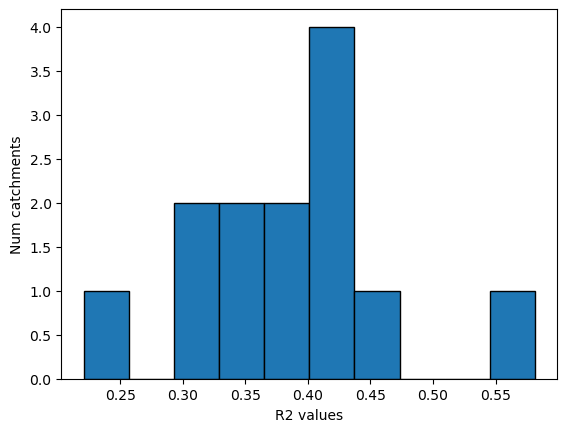

In [7]:
plt.hist(results_df['spearmans_corr'], edgecolor='black')
plt.xlabel('R2 values')
plt.ylabel("Num catchments")

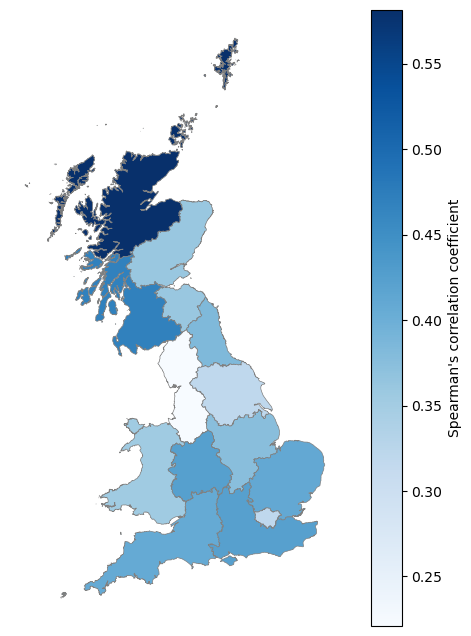

In [8]:
temp = pd.DataFrame({'geo_region': np.unique(rainfall_events_all_df["geo_region"]), 
                     'spearmans_corr': results_df['spearmans_corr']})
regions_df = regions_df.merge(temp, on='geo_region')

fig, ax = plt.subplots(figsize=(8, 8))

regions_df.plot(ax=ax,column='spearmans_corr',cmap='Blues',edgecolor='grey',linewidth=0.5,legend=True,
           legend_kwds={'label': "Spearman's correlation coefficient"})

ax.set_axis_off()

### Per catchment

In [9]:
from scipy import stats
from scipy.stats import pointbiserialr

results = []

for catchment_num in np.unique(rainfall_events_all_df["catchment_num"]):

    subset = rainfall_events_all_df[rainfall_events_all_df["catchment_num"] == catchment_num].dropna(
        subset=["max_precip", "10cm_area", "hc_at_peak"])

    n_events = len(subset)
    n_flooded = (subset["10cm_area"] > 0).sum()

    # ------------------
    # Part A: does rain predict WHETHER it floods at all?
    # ------------------
    flooded = (subset["10cm_area"] > 0).astype(int)
    if flooded.nunique() > 1:  # need at least some flooded AND some non-flooded events
        pb_r, pb_p = pointbiserialr(flooded, subset["max_precip"])
    else:
        pb_r, pb_p = np.nan, np.nan

    # ------------------
    # Part B: GIVEN it floods, does more rain mean more area?
    # ------------------
    subset_flooded = subset[subset["10cm_area"] > 0]
    if len(subset_flooded) > 5:  # arbitrary minimum - avoid noisy correlations from tiny samples
        spearmans_corr_given_flood, spearmans_p_given_flood = stats.spearmanr(
            subset_flooded["10cm_area"], subset_flooded["max_precip"])
        r2_simple_given_flood, p_simple_given_flood = find_linear_relationship(
            subset_flooded, "10cm_area", "max_precip")
    else:
        spearmans_corr_given_flood, spearmans_p_given_flood = np.nan, np.nan
        r2_simple_given_flood, p_simple_given_flood = np.nan, np.nan

    # ------------------
    # Your existing full-dataset (unsplit) metrics - kept as before
    # ------------------
    r2_simple, p_simple = find_linear_relationship(subset, "10cm_area", "max_precip")
    spearmans_corr, spearmans_p_value = stats.spearmanr(subset["10cm_area"], subset["max_precip"])

    r2_fu, p_fu = find_multiple_regress(subset, "fu_at_peak_old")
    r2_fumax, p_fumax = find_multiple_regress(subset, "fumax_at_peak")

    results.append({
        "catchment_num": catchment_num,
        "n_events": n_events,
        "n_flooded": n_flooded,
        "flood_rate": n_flooded / n_events if n_events > 0 else np.nan,

        # existing whole-sample metrics
        "r2_simple": r2_simple, "p_simple": p_simple,
        "spearmans_corr": spearmans_corr,
        "r2_fu": r2_fu, "p_fu": p_fu,
        "r2_fumax": r2_fumax, "p_fumax": p_fumax,

        # NEW: Part A - flood occurrence
        "point_biserial_r": pb_r, "point_biserial_p": pb_p,

        # NEW: Part B - flood severity given flooding occurred
        "spearmans_corr_given_flood": spearmans_corr_given_flood,
        "spearmans_p_given_flood": spearmans_p_given_flood,
        "r2_simple_given_flood": r2_simple_given_flood,
        "p_simple_given_flood": p_simple_given_flood,
    })

results_df = pd.DataFrame(results)

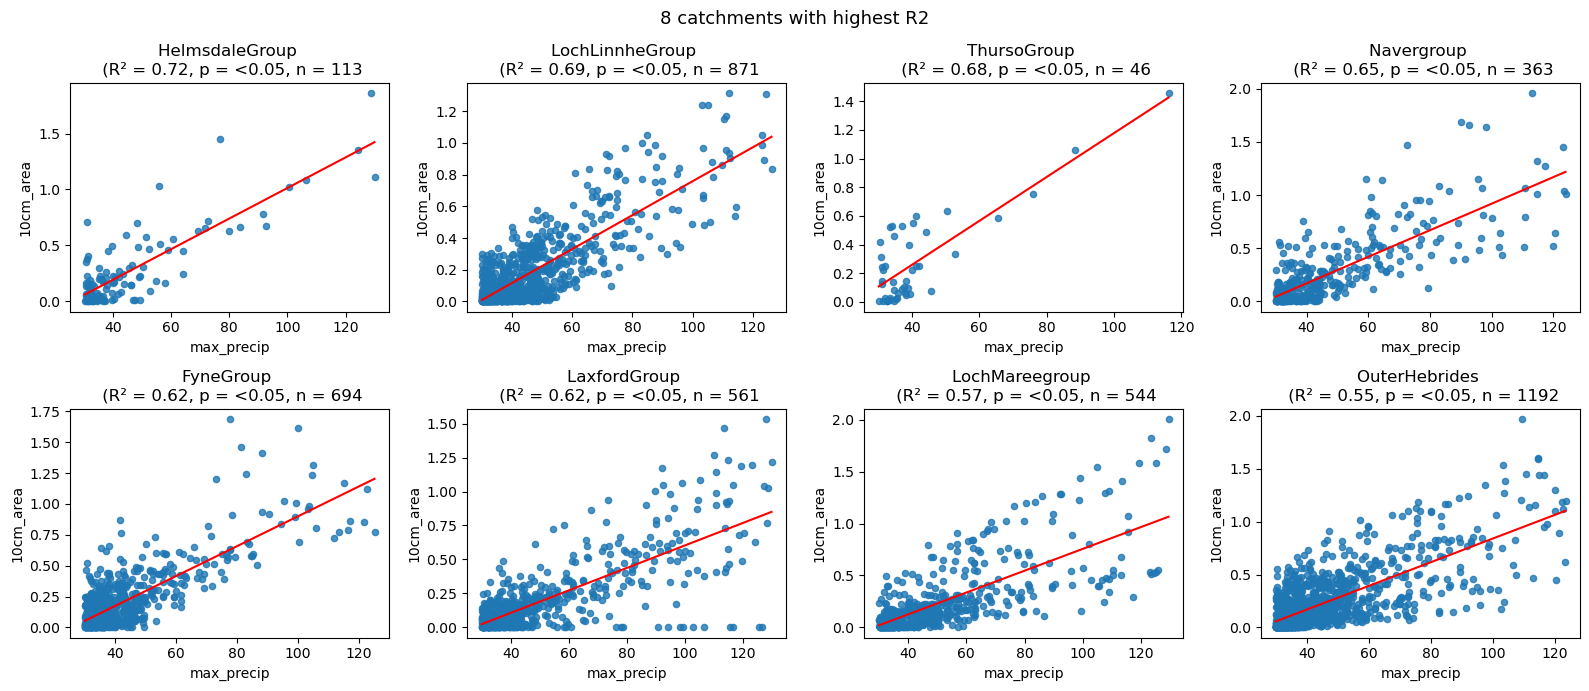

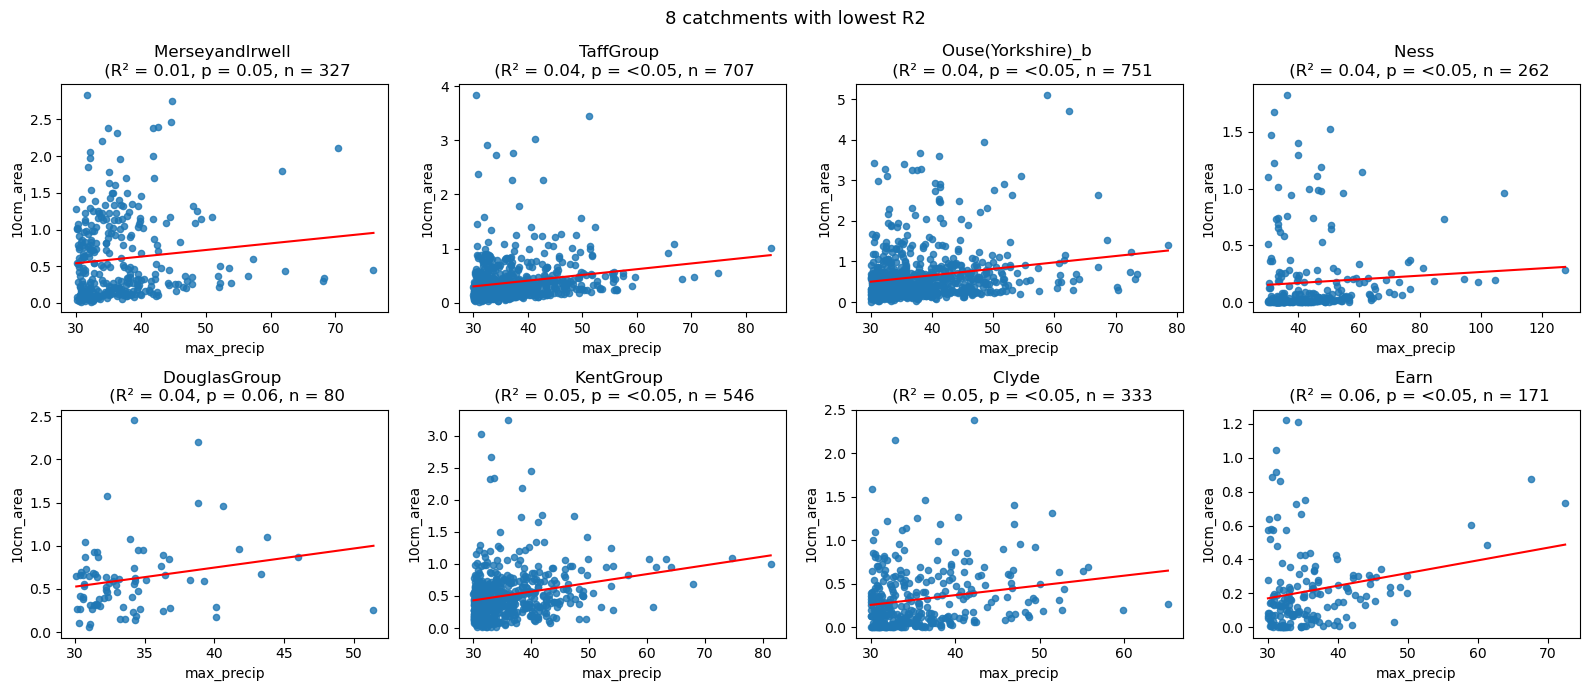

In [10]:
results = []

for catchment_num in np.unique(rainfall_events_all_df["catchment_num"]):

    subset = rainfall_events_all_df[rainfall_events_all_df["catchment_num"] == catchment_num].dropna(
        subset=["max_precip", "10cm_area", "hc_at_peak"])

    # subset = subset[subset["10cm_area"] > 0]

    # Simple: flood area ~ rainfall intensity
    r2_simple, p_simple = find_linear_relationship(subset, "10cm_area", "max_precip")
    
    spearmans_corr, spearmans_p_value = stats.spearmanr(subset["10cm_area"], subset["max_precip"])
    
    # Multiple: flood area ~ rainfall intensity + fu_at_peak
    r2_fu, p_fu = find_multiple_regress (subset, "fu_at_peak_old")
    r2_fumax, p_fumax = find_multiple_regress (subset, "fumax_at_peak")
    
    results.append({"catchment_num": catchment_num,"r2_simple": r2_simple, "p_simple": p_simple,"spearmans_corr":spearmans_corr, 
        "r2_fu": r2_fu,"p_fu": p_fu,"r2_fumax": r2_fumax, "p_fumax": p_fumax})

results_df = pd.DataFrame(results)

results_df["r2_simple"] = pd.to_numeric(results_df["r2_simple"], errors="coerce")
results_df = results_df.dropna(subset=["r2_simple"])

top8 = results_df.nlargest(8, "r2_simple")
bottom8 = results_df.nsmallest(8, "r2_simple")

plot_r2_grid(top8, "8 catchments with highest R2", "catchment_num")
plt.show()
plot_r2_grid(bottom8, "8 catchments with lowest R2", "catchment_num")
plt.show()

In [11]:
results_df = CATCHMENTS.merge(results_df, on='HA_NUM')

fig, ax = plt.subplots(figsize=(8, 8))

results_df.plot(ax=ax,column='spearmans_corr',cmap='Blues',edgecolor='grey',linewidth=0.5,legend=True,
           legend_kwds={'label': "Spearman's correlation coefficient"})

ax.set_axis_off()

# fig, axs = plt.subplots(ncols=3, figsize=(12, 4))

# stats.plot(ax=axs[0],column="spearmans_corr_given_flood",cmap="Blues",edgecolor ='black', linewidth=0.2,legend=False, 
#                 label='Difference in R2')
# axs[0].set_axis_off()
# # axs[0].set_title("R2 : linear regression using max_precip");

# stats.plot(ax=axs[1],column="spearmans_corr",cmap="Blues",edgecolor ='black', linewidth=0.2,
#                 legend=False, label='Difference in R2')
# axs[1].set_axis_off()
# # axs[1].set_title("R2 : linear regression using max_precip");

# stats.plot(ax=axs[2],column="r2_simple",cmap="Blues",edgecolor ='black', linewidth=0.2,
#                 legend=False, label='Difference in R2')
# axs[2].set_axis_off()
# # axs[2].set_title("R2 : linear regression using max_precip");

KeyError: 'HA_NUM'

In [ ]:
results_df['diff_r2'] = results_df['r2_fumax'] -  results_df['r2_simple']
results_df['diff_r2_fumax_fu'] = results_df['r2_fumax'] -  results_df['r2_fu']
temp = pd.DataFrame({'HA_NUM': CATCHMENTS['HA_NUM'], 'r2_value': stats['diff_r2_fumax_fu']})
temp = CATCHMENTS.merge(temp, on='HA_NUM')

max_abs = np.nanmax(np.abs(temp["r2_value"]))

fig, ax = plt.subplots(figsize=(8, 8))

temp.plot(ax=ax,column="r2_value",cmap="RdYlGn",edgecolor="grey",linewidth=0.5,legend=True,vmin=-max_abs,vmax=max_abs,
         label='Difference in R2')

ax.set_axis_off()
ax.set_title("Positive values = Fumax > Fu \nStatic soil properties more important than initial conditions");

In [ ]:
plt.hist(stats['spearmans_corr'], edgecolor='black')
plt.xlabel('Spearmans corr coefficient')
plt.ylabel("Num catchments")

### Per individual pixel

In [ ]:
cols = ["x_idx_global", "y_idx_global"]
rainfall_events_all_df["peak_cell_id"] = rainfall_events_all_df.groupby(cols, sort=False).ngroup()

In [ ]:
xvar, yvar = "max_precip", "10cm_area"

# Apply the same NaN filter the regression uses, *before* counting,
# so ">20 events" means >20 usable events
clean = rainfall_events_all_df.dropna(subset=[xvar, yvar, "hc_at_peak"])
clean = clean[clean["peak_cell_id"] >= 0]      # ngroup gives -1 for NaN indices

counts = clean["peak_cell_id"].value_counts()
busy_ids = counts[counts > 20].index
print(f"{len(busy_ids)} pixels with >20 events")

# R² and p for each busy pixel
rows = []
for pid, sub in clean[clean["peak_cell_id"].isin(busy_ids)].groupby("peak_cell_id"):
    r2, p = find_linear_relationship(sub, yvar, xvar)
    spearmans_corr, spearmans_p_value = stats.spearmanr(sub[yvar], sub[xvar])
    rows.append({"peak_cell_id": pid, "r2": r2, "p": p, "n": len(sub),
                 "x_idx_global": sub["x_idx_global"].iloc[0],
                 "y_idx_global": sub["y_idx_global"].iloc[0],
                 "spearmans_corr_coefficient":spearmans_corr,
                "x_coord": sub["x_coord"].iloc[0],
                "y_coord": sub["y_coord"].iloc[0],})

pix_stats = pd.DataFrame(rows)
pix_stats[["spearmans_corr_coefficient"]] = pix_stats[["spearmans_corr_coefficient"]].apply(pd.to_numeric, errors="coerce")
pix_stats = pix_stats.dropna(subset=["spearmans_corr_coefficient"])

top8 = pix_stats.nlargest(8, "spearmans_corr_coefficient")
bottom8 = pix_stats.nsmallest(8, "spearmans_corr_coefficient")

def plot_pixel_grid(stats_sub, suptitle):
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.ravel()
    for ax, (_, row) in zip(axes, stats_sub.iterrows()):
        sub = clean[clean["peak_cell_id"] == row["peak_cell_id"]]
        ax.scatter(sub[xvar], sub[yvar], s=12, alpha=0.6)
        m, c = np.polyfit(sub[xvar], sub[yvar], 1)
        xs = np.linspace(sub[xvar].min(), sub[xvar].max(), 50)
        ax.plot(xs, m * xs + c, color="red", lw=1.5)
        ax.set_title(f"cell ({int(row['x_idx_global'])}, {int(row['y_idx_global'])})  "
                     f"Spearmans corr={row['spearmans_corr_coefficient']:.2f}, p={row['p']}, n={int(row['n'])}", fontsize=9)
        ax.set_xlabel(xvar); ax.set_ylabel(yvar)
    for ax in axes[len(stats_sub):]:
        ax.set_visible(False)
    fig.suptitle(suptitle, fontsize=13)
    fig.tight_layout()
    return fig

plot_pixel_grid(top8, "Pixels (>20 events) with highest R²"); plt.show()
plot_pixel_grid(bottom8, "Pixels (>20 events) with lowest R²"); plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))    
CATCHMENTS.boundary.plot(ax=ax, edgecolor="grey", linewidth=0.5)
sc = ax.scatter(pix_stats["x_coord"], pix_stats["y_coord"], c=pix_stats['r2'], cmap='YlRdBl',
                s=20, marker="s", edgecolor="k", linewidth=0.3)
fig.colorbar(sc, ax=ax, shrink=0.7, label='Spearmans Correlation Coefficient')
ax.set_aspect("equal")

In [ ]:
plt.hist(pix_stats['spearmans_corr_coefficient'], edgecolor='black')
plt.xlabel('Spearmans Correlation Coefficient')
plt.ylabel("Num pixels")

### Closer look at pixels with repeated 0 flood values

In [ ]:
cols = ["x_idx_global", "y_idx_global"]
yvar, xvar = "10cm_area", "max_precip"

df = rainfall_events_all_df.copy()
df["peak_cell_id"] = df.groupby(cols, sort=False).ngroup()
df = df[df["peak_cell_id"] >= 0]                       # drop rows with NaN indices

df["is_zero"] = df[yvar] == 0                          # NaN areas count as False

pix = df.groupby("peak_cell_id").agg(n_events=("is_zero", "size"),n_zero=("is_zero", "sum"),)
pix["frac_zero"] = pix["n_zero"] / pix["n_events"]

# rank by number of zeros
top_ids = pix.sort_values("n_zero", ascending=False).index[:30]

# check which catchment has the most 0s
sub = df[df["peak_cell_id"] == 7390]
np.unique(sub['catchment_num'])

catchment96 = CATCHMENTS[CATCHMENTS['HA_NUM']=="6"]
fig, ax = plt.subplots()
CATCHMENTS.boundary.plot(ax=ax, color = None, edgecolor="grey", linewidth=0.5)
catchment96.boundary.plot(ax=ax, color = 'blue', edgecolor="grey", linewidth=0.5)

In [ ]:
fig, axs = plt.subplots(ncols=5, nrows=6, figsize=(15, 15))
axs = axs.flatten()

for ax, pid in zip(axs, top_ids):
    sub = df[df["peak_cell_id"] == pid]
    ax.scatter(sub[xvar], sub[yvar], s=20, alpha=0.8)
    ax.set_title(f"cell {pid}: {int(pix.loc[pid, 'n_zero'])}/{int(pix.loc[pid, 'n_events'])} zero",
                 fontsize=16)

for ax in axs[len(top_ids):]:
    ax.set_visible(False)

fig.tight_layout()
plt.show()

In [ ]:
# zeros = df[df['is_zero']==True]
# zeros_6 = zeros[zeros['catchment_num']=='6']
# zeros_6[['catchment_num', 'ens', 'event_num', 'start_year', 'max_precip', '10cm_area']][:20]

In [ ]:
# df[df['is_zero']==True][['catchment_num', 'ens', 'event_num', 'start_year', 'max_precip', '10cm_area']][:100]

In [ ]:
# cands = ["hc_at_peak", "max_precip"]   # add: saturation at peak, fu_at_peak, lu_at_peak,
#                                        # urban/waterbody proportion, event duration/volume...
# print(wet.groupby("is_zero")[cands].describe().T)

# # HC vs frac zero, one dot per cell
# ax = cell.plot.scatter("hc", "frac_zero", c="n_wet", cmap="viridis", figsize=(6, 4))

In [ ]:
xvar, yvar = "max_precip", "10cm_area"
RAIN_THRESH = 30      # what counts as "lots of rain" (mm), adjust
MIN_WET = 10           # min heavy-rain events per cell to be shown

df = rainfall_events_all_df.dropna(subset=[xvar, yvar]).copy()
wet = df[df[xvar] >= RAIN_THRESH].copy()
wet["is_zero"] = wet[yvar] <= 0

# one row per peak cell (per catchment, in case a cell is the peak for neighbouring catchments)
cell = (wet.groupby(["catchment_num", "x_idx_global", "y_idx_global"])
           .agg(n_wet=("is_zero", "size"),
                n_zero=("is_zero", "sum"),
                x_coord=("x_coord", "first"),
                y_coord=("y_coord", "first"),
               fu=("fu_at_peak_old", "mean"))
           .reset_index())
cell["frac_zero"] = cell["n_zero"] / cell["n_wet"]
cell = cell[cell["n_wet"] >= MIN_WET]
# cell = cell[cell['frac_zero']>0.1]

# --- maps ---
fig, axs = plt.subplots(1, 2, figsize=(10, 7), sharex=True, sharey=True)

for ax, col, cmap, label in [
    (axs[0], "frac_zero", "Blues", f"Fraction of events ≥{RAIN_THRESH} mm with zero flooding"),
    (axs[1], "fu",        "magma_r", "Mean HC at peak cell"),]:
    
    CATCHMENTS.boundary.plot(ax=ax, edgecolor="grey", linewidth=0.5)
    sc = ax.scatter(cell["x_coord"], cell["y_coord"], c=cell[col], cmap=cmap,
                    s=10, marker="s", edgecolor="k", linewidth=0.3)
    fig.colorbar(sc, ax=ax, shrink=0.7, label=label)
    ax.set_aspect("equal")
    ax.set_title(label, fontsize=10)

# zoom to where the cells are
pad = 10_000
axs[0].set_xlim(cell["x_coord"].min() - pad, cell["x_coord"].max() + pad)
axs[0].set_ylim(cell["y_coord"].min() - pad, cell["y_coord"].max() + pad)
plt.tight_layout()
plt.show()

In [ ]:
cols = ["x_idx_global", "y_idx_global"]

step0 = df0 = rainfall_events_all_df.dropna(subset=cols)
n0 = step0.groupby(cols).size()
print("pixels, all events:          ", len(n0), "| with >50 events:", (n0 > 50).sum())

step1 = step0.dropna(subset=["max_precip", "10cm_area"])
n1 = step1.groupby(cols).size()
print("after dropna on precip/area: ", len(n1), "| with >50 events:", (n1 > 50).sum())

step2 = step1[step1["max_precip"] >= RAIN_THRESH]
n2 = step2.groupby(cols).size()
print(f"after precip >= {RAIN_THRESH}:          ", len(n2), "| with >=3 events:", (n2 >= 3).sum())

print("cells split across catchments:",
      (step0.groupby(cols)["catchment_num"].nunique() > 1).sum())

In [ ]:
# subset = rainfall_events_all_df

# for i, region in enumerate(np.unique(rainfall_events_all_df['catchment_num'])):
#     print(region)
#     subset = rainfall_events_all_df[
#         rainfall_events_all_df["catchment_num"] == region].dropna(subset=["max_precip", "10cm_area", "hc_at_peak"])
    
#     # Simple regression: flood area ~ rainfall intensity
#     r2_simple, p_value = find_linear_relationship("max_precip")
#     if r2_simple>0.6:
#         plt.scatter(subset['max_precip'], subset['10cm_area'])
#         plt.show()
# #     # ------------------------
# #     find_linear_relationship_with_max_precip("fu_at_peak_old_mm")    
    
# #     # ------------------------    
# #     find_linear_relationship_with_max_precip("hc_at_peak")    
    
# #     # ------------------------    
# #     find_linear_relationship_with_max_precip("fumax_at_peak") 
    
# #     # ------------------------
# #     find_linear_relationship_with_max_precip("hc_at_peak", "fu_at_peak_old_mm")